<a href="https://colab.research.google.com/github/HakureiPOI/coinmetrics-fetcher/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install git+https://github.com/HakureiPOI/coinmetrics-fetcher.git -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
os.environ['COINMETRICS_API_KEY'] = '<YOUR_COINMETRICS_API_KEY>'

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
from api import SpotDataFetcher

spot = SpotDataFetcher()

In [5]:
# 获取 BTC 现货 K 线
df = spot.get_candles(
    exchange='deribit',
    base='btc',
    start_time='2026-01-01',
    end_time='2026-01-02',
    frequency='1m'
)

04:02:07 INFO    [现货 K 线] DERIBIT BTC | 3 个市场 | 1m
04:02:07 INFO    [现货 K 线]  1/1 | 累计   4320 条
04:02:07 INFO    [现货 K 线] 完成：1/1 批次，共 4320 条
04:02:07 INFO    [现货 K 线] 完成：4320 条


In [6]:
df.head()

,market,time,price_open,price_close,price_high,price_low,vwap,volume,candle_usd_volume,candle_trades_count,symbol,pair
0,deribit-btc-usdc-spot,2026-01-01 00:00:00+00:00,87496,87523,87530,87496,87517.367747,0.1327,11610.976638,6,BTC_USDC,btc-usdc
1,deribit-btc-usdc-spot,2026-01-01 00:01:00+00:00,87510,87559,87559,87510,87548.472222,0.0216,1889.912952,8,BTC_USDC,btc-usdc
2,deribit-btc-usdc-spot,2026-01-01 00:02:00+00:00,87559,87559,87559,87545,87557.385635,0.0905,7922.008000,6,BTC_USDC,btc-usdc
3,deribit-btc-usdc-spot,2026-01-01 00:03:00+00:00,87559,87559,87559,87559,87557.385635,0.0000,0.000000,0,BTC_USDC,btc-usdc
4,deribit-btc-usdc-spot,2026-01-01 00:04:00+00:00,87576,87576,87576,87576,87576.000000,0.0001,8.755000,1,BTC_USDC,btc-usdc


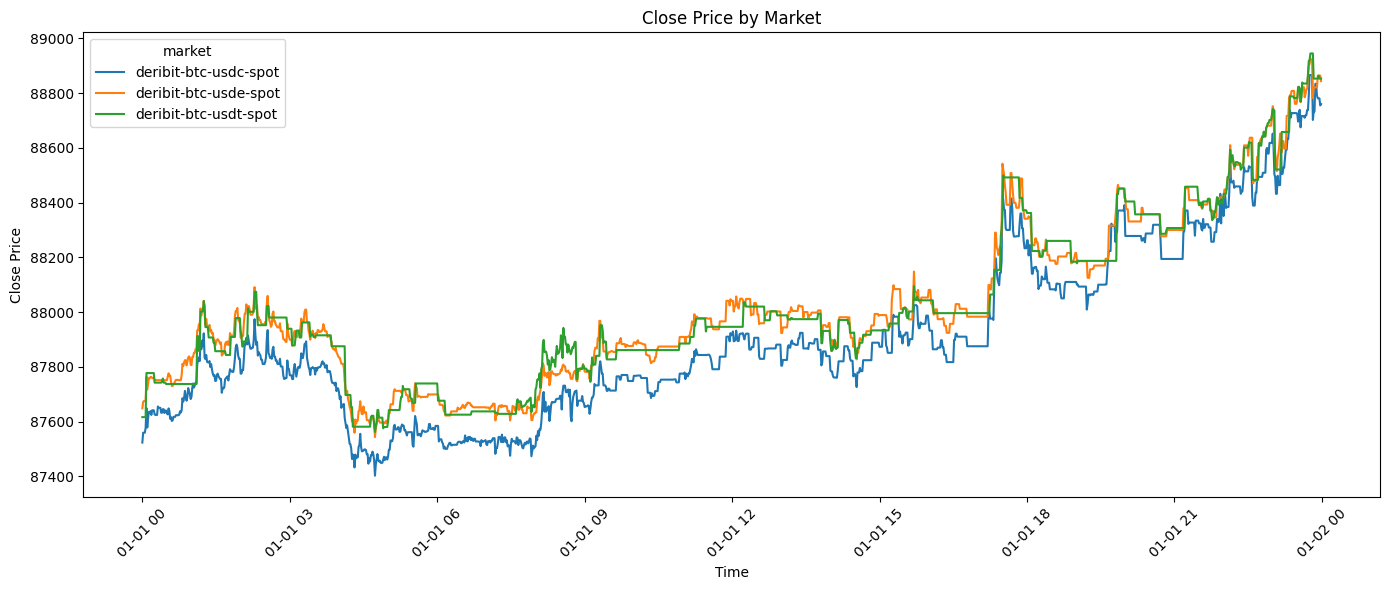

In [7]:
df2 = df.sort_values(["market", "time"]).copy()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df2,
    x="time",
    y="price_close",
    hue="market",
    estimator=None
)
plt.title("Close Price by Market")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# 指定计价货币
df = spot.get_candles(
    exchange='binance',
    base='btc',
    quote='usdt',  # 只获取 BTC/USDT
    start_time='2026-01-01',
    end_time='2026-01-02',
    frequency='1m'
)

04:02:09 INFO    [现货 K 线] BINANCE BTC (USDT) | 1 个市场 | 1m
04:02:09 INFO    [现货 K 线]  1/1 | 累计   1440 条
04:02:09 INFO    [现货 K 线] 完成：1/1 批次，共 1440 条
04:02:10 INFO    [现货 K 线] 完成：1440 条


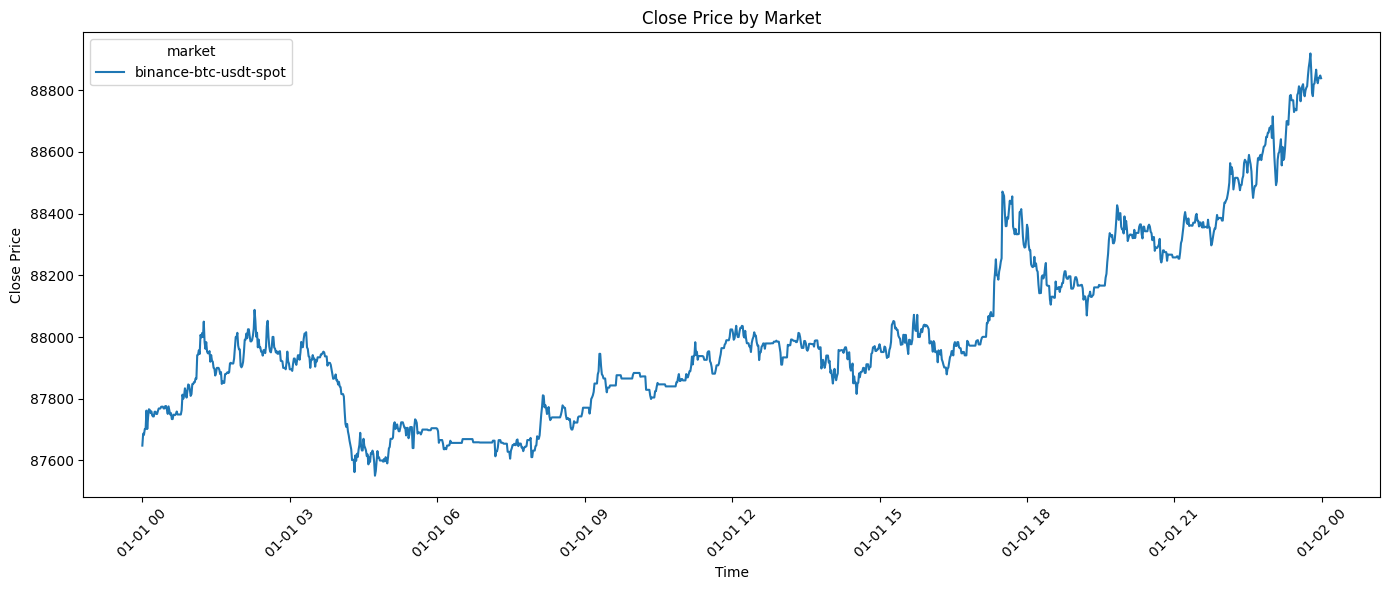

In [9]:
df2 = df.sort_values(["market", "time"]).copy()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df2,
    x="time",
    y="price_close",
    hue="market",
    estimator=None
)
plt.title("Close Price by Market")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
from api import FuturesDataFetcher

futures = FuturesDataFetcher()

In [11]:
df = futures.get_candles(
    exchange='deribit',
    base='btc',
    start_time='2026-01-01',
    end_time='2026-01-02',
    frequency='1m'
)

04:02:13 INFO    [K 线] DERIBIT BTC | 322 个市场 | 1m
04:02:13 INFO    [K 线]  2/7 | 累计      0 条
04:02:13 INFO    [K 线]  3/7 | 累计      0 条
04:02:13 INFO    [K 线]  1/7 | 累计      0 条
04:02:13 INFO    [K 线]  6/7 | 累计      0 条
04:02:14 INFO    [K 线]  5/7 | 累计   2880 条
04:02:14 INFO    [K 线]  4/7 | 累计  10080 条
04:02:14 INFO    [K 线]  7/7 | 累计  15840 条
04:02:14 INFO    [K 线] 完成：3/7 批次，共 15840 条
04:02:14 INFO    [K 线] 完成：15840 条


In [12]:
df.head()

,market,time,price_open,price_close,price_high,price_low,vwap,volume,candle_usd_volume,candle_trades_count,symbol,pair
0,deribit-BTC-25DEC26-future,2026-01-01 00:00:00+00:00,91592.5,91592.5,91592.5,91592.5,91592.5,0,0.0,0,BTC-25DEC26,btc-usd
1,deribit-BTC-25DEC26-future,2026-01-01 00:01:00+00:00,91592.5,91592.5,91592.5,91592.5,91592.5,0,0.0,0,BTC-25DEC26,btc-usd
2,deribit-BTC-25DEC26-future,2026-01-01 00:02:00+00:00,91592.5,91592.5,91592.5,91592.5,91592.5,0,0.0,0,BTC-25DEC26,btc-usd
3,deribit-BTC-25DEC26-future,2026-01-01 00:03:00+00:00,91592.5,91592.5,91592.5,91592.5,91592.5,0,0.0,0,BTC-25DEC26,btc-usd
4,deribit-BTC-25DEC26-future,2026-01-01 00:04:00+00:00,91592.5,91592.5,91592.5,91592.5,91592.5,0,0.0,0,BTC-25DEC26,btc-usd


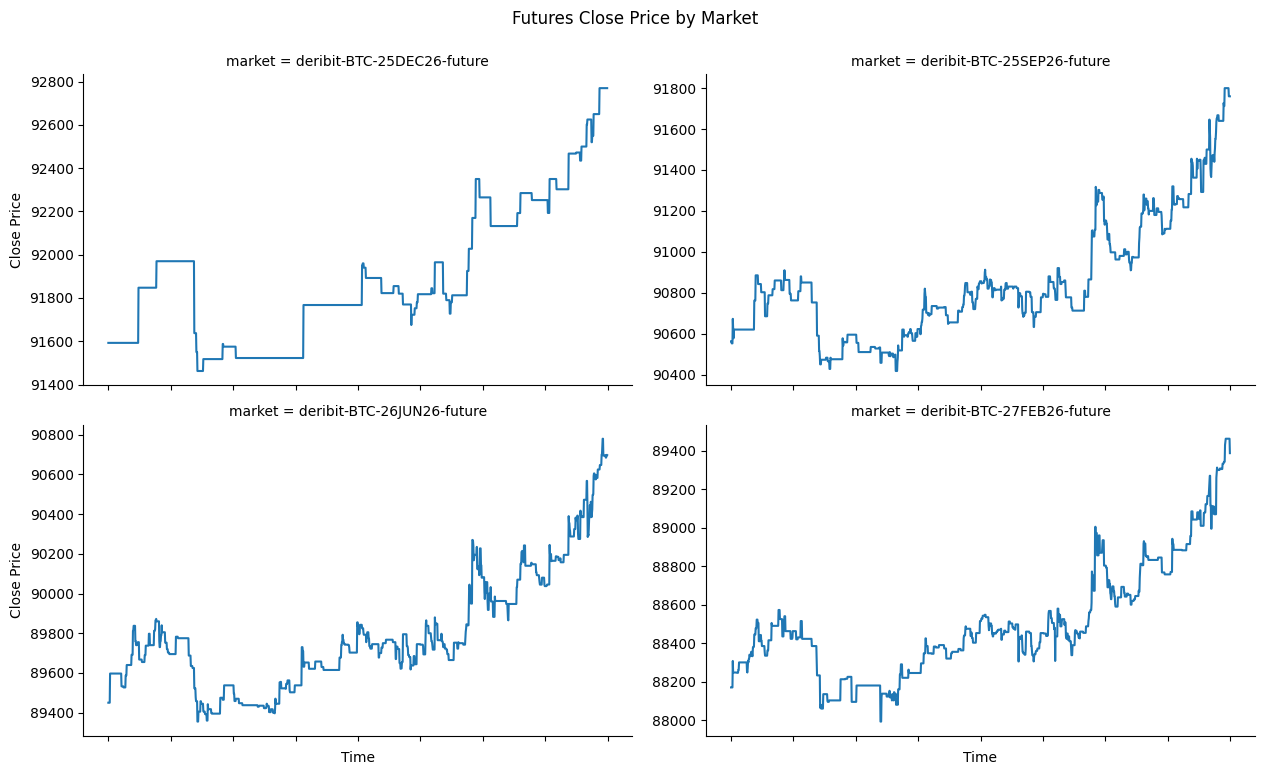

In [13]:
df2 = df.sort_values(["market", "time"]).copy()

# 这里只示例挑前4个 market
top_markets = df2["market"].drop_duplicates().iloc[:4]
df_plot = df2[df2["market"].isin(top_markets)]

g = sns.relplot(
    data=df_plot,
    x="time",
    y="price_close",
    kind="line",
    col="market",
    col_wrap=2,
    height=4,
    aspect=1.6,
    estimator=None,
    facet_kws={"sharey": False, "sharex": True}
)

g.set_xticklabels(rotation=45)
g.set_axis_labels("Time", "Close Price")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Futures Close Price by Market")
plt.show()

In [14]:
from api import OptionsDataFetcher

options = OptionsDataFetcher()

In [15]:
# 获取 Deribit BTC 期权的 Greeks 和隐含波动率
df = options.get_options_greeks_iv(
    exchange='deribit',
    base='btc',
    start_time='2026-01-01',
    end_time='2026-01-02',
    granularity='1h',      # 数据粒度：raw, 1m, 1h, 1d
    batch_size=100,        # 每批市场数
    max_workers=4          # 并发数
)

04:02:29 INFO    [Greeks/IV] DERIBIT BTC | 1116 个期权
04:02:32 INFO    [Greeks]  1/12 | 累计   1804 条
04:02:32 INFO    [Greeks]  3/12 | 累计   4304 条
04:02:32 INFO    [Greeks]  2/12 | 累计   6804 条
04:02:32 INFO    [Greeks]  4/12 | 累计   9304 条
04:02:34 INFO    [Greeks]  5/12 | 累计  11804 条
04:02:34 INFO    [Greeks]  8/12 | 累计  13852 条
04:02:35 INFO    [Greeks]  7/12 | 累计  15884 条
04:02:35 INFO    [Greeks]  6/12 | 累计  18384 条
04:02:36 INFO    [Greeks] 12/12 | 累计  18784 条
04:02:37 INFO    [Greeks]  9/12 | 累计  21284 条
04:02:37 INFO    [Greeks] 10/12 | 累计  23784 条
04:02:37 INFO    [Greeks] 11/12 | 累计  26086 条
04:02:37 INFO    [Greeks] 完成：12/12 批次，共 26086 条
04:02:39 INFO    [IV]  1/12 | 累计   1804 条
04:02:40 INFO    [IV]  3/12 | 累计   4304 条
04:02:40 INFO    [IV]  2/12 | 累计   6804 条
04:02:40 INFO    [IV]  4/12 | 累计   9304 条
04:02:41 INFO    [IV]  5/12 | 累计  11804 条
04:02:42 INFO    [IV]  8/12 | 累计  13852 条
04:02:42 INFO    [IV]  7/12 | 累计  15884 条
04:02:42 INFO    [IV]  6/12 | 累计  18384 条
04:02:43 INF

In [16]:
df.head()

,market,time,database_time_greeks,vega,theta,rho,delta,gamma,exchange_time_greeks,database_time_iv,iv_bid,iv_ask,iv_mark,exchange_time_iv,strike,expiration,option_contract_type,listing
0,deribit-BTC-16JAN26-100000-C-option,2026-01-01 00:00:00+00:00,2026-01-01 00:00:12.016853+00:00,26.37470,-37.70077,2.78313,0.07861,0.00002,2026-01-01 00:00:10.111000+00:00,2026-01-01 00:00:12.016853+00:00,0.4323,0.4455,0.4384,2026-01-01 00:00:10.111000+00:00,100000,2026-01-16 08:00:00,call,2025-12-25 08:00:12
1,deribit-BTC-16JAN26-100000-C-option,2026-01-01 01:00:00+00:00,2026-01-01 01:00:08.897600+00:00,26.76380,-38.11836,2.83359,0.08009,0.00002,2026-01-01 01:00:08.338000+00:00,2026-01-01 01:00:08.897600+00:00,0.4281,0.4412,0.4356,2026-01-01 01:00:08.338000+00:00,100000,2026-01-16 08:00:00,call,2025-12-25 08:00:12
2,deribit-BTC-16JAN26-100000-C-option,2026-01-01 02:00:00+00:00,2026-01-01 02:00:04.983819+00:00,27.22592,-38.80957,2.89439,0.08191,0.00002,2026-01-01 02:00:03.534000+00:00,2026-01-01 02:00:04.983819+00:00,0.4282,0.4412,0.4348,2026-01-01 02:00:03.534000+00:00,100000,2026-01-16 08:00:00,call,2025-12-25 08:00:12
3,deribit-BTC-16JAN26-100000-C-option,2026-01-01 03:00:00+00:00,2026-01-01 03:00:02.002467+00:00,27.19025,-39.04741,2.88670,0.08196,0.00002,2026-01-01 03:00:01.719000+00:00,2026-01-01 03:00:02.002467+00:00,0.4298,0.4396,0.4368,2026-01-01 03:00:01.719000+00:00,100000,2026-01-16 08:00:00,call,2025-12-25 08:00:12
4,deribit-BTC-16JAN26-100000-C-option,2026-01-01 04:00:00+00:00,2026-01-01 04:00:03.025487+00:00,26.80599,-38.64512,2.83117,0.08065,0.00002,2026-01-01 04:00:00.948000+00:00,2026-01-01 04:00:03.025487+00:00,0.4323,0.4421,0.4373,2026-01-01 04:00:00.948000+00:00,100000,2026-01-16 08:00:00,call,2025-12-25 08:00:12


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26086 entries, 0 to 26085
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   market                26086 non-null  object             
 1   time                  26086 non-null  datetime64[ns, UTC]
 2   database_time_greeks  26086 non-null  datetime64[ns, UTC]
 3   vega                  26086 non-null  float64            
 4   theta                 26086 non-null  float64            
 5   rho                   26086 non-null  float64            
 6   delta                 26086 non-null  float64            
 7   gamma                 26086 non-null  float64            
 8   exchange_time_greeks  26086 non-null  datetime64[ns, UTC]
 9   database_time_iv      26086 non-null  datetime64[ns, UTC]
 10  iv_bid                26086 non-null  float64            
 11  iv_ask                26086 non-null  float64            
 12  iv_m

In [18]:
from api import FundingRateFetcher

funding = FundingRateFetcher()

In [19]:
# 获取实际资金费率
df = funding.get_funding_rates(
    exchange='deribit',
    base='btc',
    start_time='2026-01-01',
    end_time='2026-02-01'
)

04:02:44 INFO    [资金费率] DERIBIT BTC | 3 个市场
04:02:45 INFO    [资金费率]  1/1 | 累计   1488 条
04:02:45 INFO    [资金费率] 完成：1/1 批次，共 1488 条
04:02:45 INFO    [资金费率] 完成：1488 条


In [20]:
df.head()

,market,time,database_time,rate,period,interval,symbol,pair
0,deribit-BTC-PERPETUAL-future,2026-01-01 00:00:00+00:00,2026-01-01 00:00:02.024637+00:00,0.000090,08:00:00,00:00:00.001,BTC-PERPETUAL,btc-usd
1,deribit-BTC-PERPETUAL-future,2026-01-01 01:00:00+00:00,2026-01-01 01:00:01.166037+00:00,0.000097,08:00:00,00:00:00.001,BTC-PERPETUAL,btc-usd
2,deribit-BTC-PERPETUAL-future,2026-01-01 02:00:00+00:00,2026-01-01 02:00:01.296900+00:00,0.000108,08:00:00,00:00:00.001,BTC-PERPETUAL,btc-usd
3,deribit-BTC-PERPETUAL-future,2026-01-01 03:00:00+00:00,2026-01-01 03:00:03.731134+00:00,0.000122,08:00:00,00:00:00.001,BTC-PERPETUAL,btc-usd
4,deribit-BTC-PERPETUAL-future,2026-01-01 04:00:00+00:00,2026-01-01 04:00:01.283778+00:00,0.000188,08:00:00,00:00:00.001,BTC-PERPETUAL,btc-usd


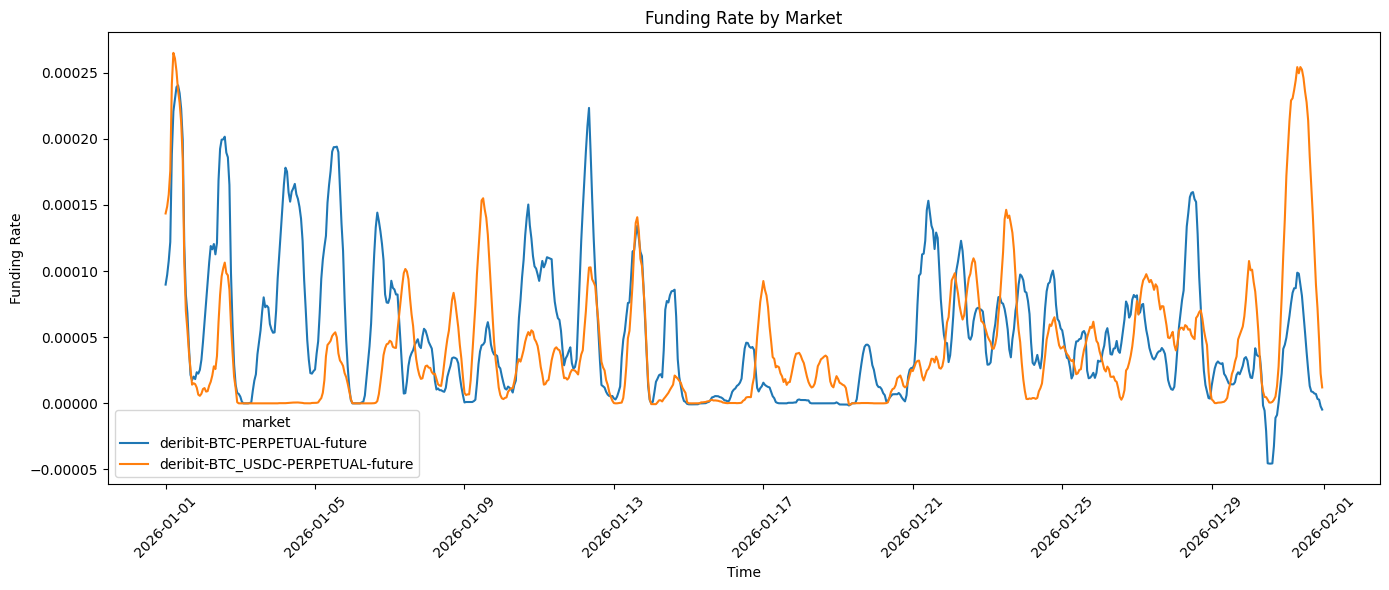

In [21]:
df2 = df.sort_values(["market", "time"]).copy()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df2,
    x="time",
    y="rate",
    hue="market",
    estimator=None
)
plt.title("Funding Rate by Market")
plt.xlabel("Time")
plt.ylabel("Funding Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()